In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


## Load the Cleaned Data

In [2]:
df = pd.read_csv("../data/accounts_cleaned.csv")
df.head()
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  str    
 2   Gender           10000 non-null  str    
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
 11  ACV              10000 non-null  float64
 12  Tenure_Years     10000 non-null  float64
 13  ACV_Band         10000 non-null  str    
dtypes: float64(4), int64(7), str(3)
memory usage: 1.1 MB


## Select Features for Clustering

In [3]:
features = ["ACV", "Tenure_Years", "NumOfProducts", "IsActiveMember"]

X = df[features].copy()
X.head()


,ACV,Tenure_Years,NumOfProducts,IsActiveMember
0,0.00,0.166667,1,1
1,83807.86,0.083333,1,1
2,159660.80,0.666667,3,0
3,0.00,0.083333,2,0
4,125510.82,0.166667,1,1


##  Scale Features

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


##  Choose Number of Clusters (Elbow Method)

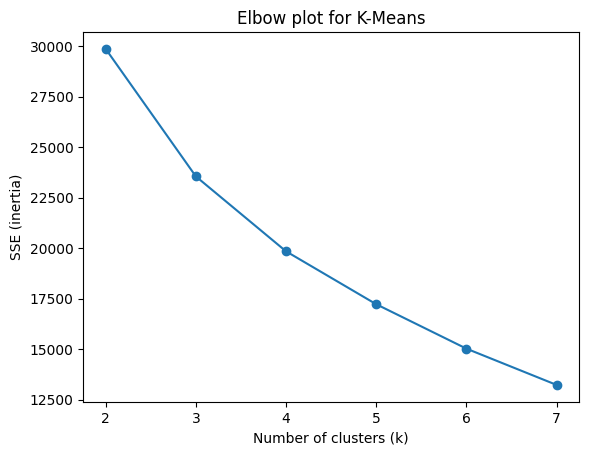

In [5]:
sse = []  # sum of squared errors

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)

plt.plot(range(2, 8), sse, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("SSE (inertia)")
plt.title("Elbow plot for K-Means")
plt.show()


In [6]:
k_opt = 4
kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
df["Segment"] = kmeans.fit_predict(X_scaled)
df["Segment"].value_counts(normalize=True)


Segment
0    0.3012
3    0.2746
2    0.2139
1    0.2103
Name: proportion, dtype: float64

##  Profile and Name Segments

In [7]:
segment_profile = df.groupby("Segment").agg(
    Accounts=("Segment", "count"),
    Avg_ACV=("ACV", "mean"),
    Avg_Tenure=("Tenure_Years", "mean"),
    Avg_Products=("NumOfProducts", "mean"),
    Churn_Rate=("Exited", "mean")
).reset_index()

segment_profile["Accounts_%"] = segment_profile["Accounts"] / len(df) * 100
segment_profile


,Segment,Accounts,Avg_ACV,Avg_Tenure,Avg_Products,Churn_Rate,Accounts_%
0,0,3012,122274.392673,0.401671,1.298141,0.155046,30.12
1,1,2103,15743.434413,0.419639,1.871136,0.226819,21.03
2,2,2139,10539.424376,0.424381,1.870033,0.125292,21.39
3,3,2746,124150.091347,0.428714,1.258922,0.300437,27.46


In [8]:
label_map = {
    0: "Strategic Enterprise",
    1: "Small Trial / At-Risk",
    2: "Growth Accounts",
    3: "High-Spend Risky"
}
df["Segment_Label"] = df["Segment"].map(label_map)


## Save with Segments

In [9]:
df.to_csv("../data/accounts_with_segments.csv", index=False)
